# **Housing Market Prediction**

## **Load Data**

In [4]:
import pandas as pd
housing = pd.read_csv("/content/Housing.csv")
housing = pd.get_dummies(housing, drop_first=True)
housing

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,True,False,True,False,False,False,False,True
541,1767150,2400,3,1,1,0,False,False,False,False,False,False,True,False
542,1750000,3620,2,1,1,0,True,False,False,False,False,False,False,True
543,1750000,2910,3,1,1,0,False,False,False,False,False,False,False,False


## **Data Preparation**


### Data Separation as X and Y

In [5]:
y = housing['price']
y

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000
...,...
540,1820000
541,1767150
542,1750000
543,1750000


In [6]:
x = housing.drop('price', axis=1)
x

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,7420,4,1,2,2,True,True,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,2,True,False,True,False,False,False,False,True
541,2400,3,1,1,0,False,False,False,False,False,False,True,False
542,3620,2,1,1,0,True,False,False,False,False,False,False,True
543,2910,3,1,1,0,False,False,False,False,False,False,False,False


### Data Splitting

In [7]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42)

In [8]:
x_train

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
46,6000,3,2,4,1,True,False,False,False,True,False,False,False
93,7200,3,2,1,3,True,False,True,False,True,False,True,False
335,3816,2,1,1,2,True,False,True,False,True,False,False,False
412,2610,3,1,2,0,True,False,True,False,False,True,False,True
471,3750,3,1,2,0,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,6000,4,2,4,0,True,False,False,False,True,False,False,True
106,5450,4,2,1,0,True,False,True,False,True,True,True,False
270,4500,3,2,3,1,True,False,False,True,False,False,False,False
435,4040,2,1,1,0,True,False,False,False,False,False,False,True


In [9]:
x_test

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
316,5900,4,2,2,1,False,False,True,False,False,False,False,True
77,6500,3,2,3,0,True,False,False,False,True,True,False,False
360,4040,2,1,1,0,True,False,False,False,False,False,True,False
90,5000,3,1,2,0,True,False,False,False,True,False,True,False
493,3960,3,1,1,0,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,6000,4,1,2,2,True,False,True,False,False,False,True,False
357,6930,4,1,2,1,False,False,False,False,False,False,False,False
39,6000,4,2,4,1,True,False,False,False,True,False,True,False
54,6000,3,2,2,1,True,True,False,False,True,False,True,False


##**Model Building**

###**Linear Regression**

####**Training the Model**

In [10]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

#### **Applying the model to make a prediction**

In [11]:
y_lr_train_pred = lr.predict(x_train)
y_lr_test_pred = lr.predict(x_test)


####**Evaluate Model Performance**

In [12]:
from sklearn.metrics import mean_squared_error, r2_score

lr_train_mse = mean_squared_error(y_train, y_lr_train_pred)
lr_train_r2 = r2_score(y_train, y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test, y_lr_test_pred)
lr_test_r2 = r2_score(y_test, y_lr_test_pred)

In [13]:
print('LR MSE (Train): ', lr_train_mse)
print('LR R2 (Train): ', lr_train_r2)
print('LR MSE (Test): ', lr_test_mse)
print('LR R2 (Test): ', lr_test_r2)

LR MSE (Train):  968358188440.7242
LR R2 (Train):  0.6859438988560158
LR MSE (Test):  1754318687330.6638
LR R2 (Test):  0.6529242642153184


In [14]:
lr_results = pd.DataFrame(['Linear Regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]).transpose()
lr_results.columns = ['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2']

In [15]:
lr_results

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear Regression,968358188440.724243,0.685944,1754318687330.663818,0.652924


###**Random Forest**

#### **Training the model**

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(max_depth=2, random_state=42)
rf.fit(x_train, y_train)

RandomForestRegressor(max_depth=2, random_state=42)

#### **Applying the model to make a prediction**

In [17]:
y_rf_train_pred = rf.predict(x_train)
y_rf_test_pred = rf.predict(x_test)

#### **Evaluate model performance**

In [18]:
from sklearn.metrics import mean_squared_error, r2_score

rf_train_mse = mean_squared_error(y_train, y_rf_train_pred)
rf_train_r2 = r2_score(y_train, y_rf_train_pred)

rf_test_mse = mean_squared_error(y_test, y_rf_test_pred)
rf_test_r2 = r2_score(y_test, y_rf_test_pred)

In [19]:
print('LR MSE (Train): ', rf_train_mse)
print('LR R2 (Train): ', rf_train_r2)
print('LR MSE (Test): ', rf_test_mse)
print('LR R2 (Test): ', rf_test_r2)

LR MSE (Train):  1417136169440.535
LR R2 (Train):  0.5403970705496253
LR MSE (Test):  2947752819958.508
LR R2 (Test):  0.4168143528954892


In [20]:
rf_results = pd.DataFrame(['Random Forest', rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]).transpose()
rf_results.columns = ['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2']
rf_results

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Random Forest,1417136169440.534912,0.540397,2947752819958.507812,0.416814


###**Gradient Boosting Regressor**

#### **Training the model**

In [21]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(max_depth=3, random_state=42)
gbr.fit(x_train, y_train)

GradientBoostingRegressor(random_state=42)

#### **Applying the model to make a prediction**

In [22]:
y_gbr_train_pred = gbr.predict(x_train)
y_gbr_test_pred = gbr.predict(x_test)

#### **Evaluate model performance**

In [23]:
from sklearn.metrics import mean_squared_error, r2_score

gbr_train_mse = mean_squared_error(y_train, y_gbr_train_pred)
gbr_train_r2 = r2_score(y_train, y_gbr_train_pred)

gbr_test_mse = mean_squared_error(y_test, y_gbr_test_pred)
gbr_test_r2 = r2_score(y_test, y_gbr_test_pred)

In [24]:
print('LR MSE (Train): ', gbr_train_mse)
print('LR R2 (Train): ', gbr_train_r2)
print('LR MSE (Test): ', gbr_test_mse)
print('LR R2 (Test): ', gbr_test_r2)

LR MSE (Train):  424108142514.5123
LR R2 (Train):  0.862454047178558
LR MSE (Test):  1688403924777.5098
LR R2 (Test):  0.66596489068611


In [25]:
gbr_results = pd.DataFrame({
    'Method': ['Gradient Boosting Regressor'],
    'Training MSE': [gbr_train_mse],
    'Training R2': [gbr_train_r2],
    'Test MSE': [gbr_test_mse],
    'Test R2': [gbr_test_r2]
})

gbr_results

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Gradient Boosting Regressor,4.241081e+11,0.862454,1.688404e+12,0.665965


### **Model comparison**

In [26]:
df_models = pd.concat([lr_results, rf_results, gbr_results], axis=0)
df_models

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear Regression,968358188440.724243,0.685944,1754318687330.663818,0.652924
0,Random Forest,1417136169440.534912,0.540397,2947752819958.507812,0.416814
0,Gradient Boosting Regressor,424108142514.512329,0.862454,1688403924777.509766,0.665965


In [27]:
df_models.reset_index(drop=True)

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear Regression,968358188440.724243,0.685944,1754318687330.663818,0.652924
1,Random Forest,1417136169440.534912,0.540397,2947752819958.507812,0.416814
2,Gradient Boosting Regressor,424108142514.512329,0.862454,1688403924777.509766,0.665965


## **Data Visualization**

### Linear Regression

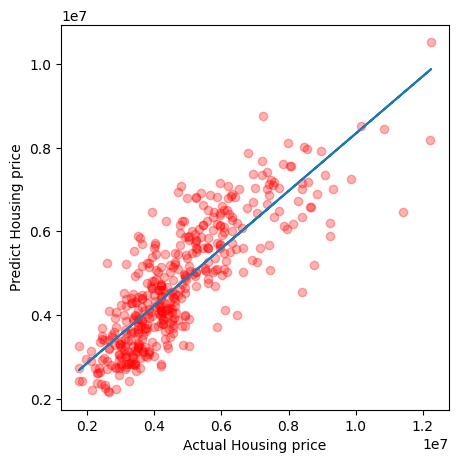

In [28]:
import matplotlib.pyplot as plt
import numpy as np


plt.figure(figsize=(5,5))
plt.scatter(x=y_train, y=y_lr_train_pred, c='#FF0000', alpha=0.3)

z = np.polyfit(y_train, y_lr_train_pred, 1)
p = np.poly1d(z)

plt.plot(y_train, p(y_train))
plt.ylabel('Predict Housing price')
plt.xlabel('Actual Housing price')

plt.show()


### Random Forest


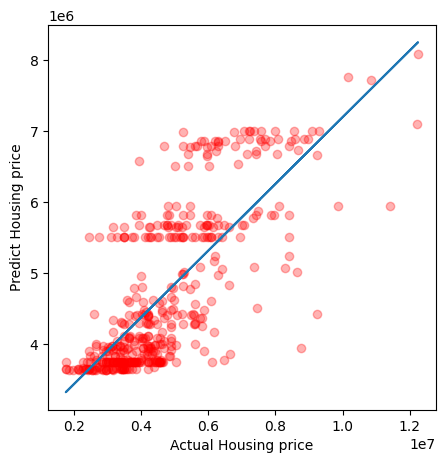

In [29]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(5,5))
plt.scatter(x=y_train, y=y_rf_train_pred, c='#FF0000', alpha=0.3)

z = np.polyfit(y_train, y_rf_train_pred, 1)
p = np.poly1d(z)

plt.plot(y_train, p(y_train))
plt.ylabel('Predict Housing price')
plt.xlabel('Actual Housing price')

plt.show()

### Gradient Boosting Regressor

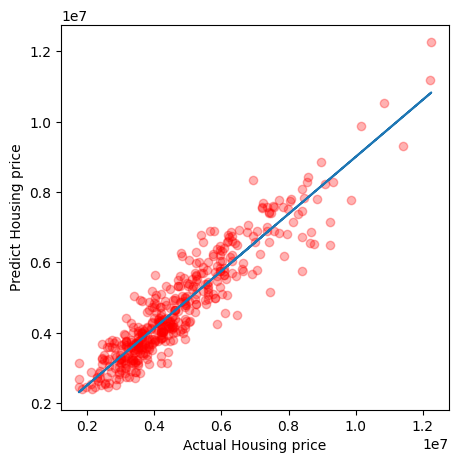

In [30]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(5,5))
plt.scatter(x=y_train, y=y_gbr_train_pred, c='#FF0000', alpha=0.3)

z = np.polyfit(y_train, y_gbr_train_pred, 1)
p = np.poly1d(z)

plt.plot(y_train, p(y_train))
plt.ylabel('Predict Housing price')
plt.xlabel('Actual Housing price')

plt.show()